# Modelica Pendulum: Basics

This tutorial introduces the pendulum model in Modelica, we simulate it as `ModelicaSystem` using `OMPython` and exports it as an FMU for co-simulation with `syssimx`.


## Overview

We use one pendulum model in two ways:

1. Simulate directly with `OMPython.ModelicaSystem`.
2. Export to FMI 2.0 Co-Simulation FMUs and simulate with `syssimx.FMUComponent`.

In both cases we compare solver behavior under the same constant torque input for different time step sizes.


## Learning Goals

- Understand the pendulum dynamics represented in Modelica.
- Understand Modelica block interfaces (`RealInput`, `RealOutput`) for tool integration.
- Compare solver behavior in direct Modelica simulation (`dassl`, `cvode`, `euler`).
- Export FMI 2.0 co-simulation FMUs and compare `cvode` vs `euler` FMU behavior.
- Understand solver constraints relevant for later hybrid/rollback tutorials.


## Prerequisites and Setup

In [1]:
from pathlib import Path
import sys
_repo = Path.cwd()
while _repo != _repo.parent and not (_repo / "pyproject.toml").exists():
    _repo = _repo.parent
sys.path.insert(0, str(_repo))

In [2]:
import numpy as np
import matplotlib.pyplot as plt

from OMPython import ModelicaSystem
from syssimx import FMUComponent

We are using `OpenModelica`:

In [3]:
from OMPython import OMCSessionZMQ
omc = OMCSessionZMQ()
omc.sendExpression("getVersion()")

'OpenModelica v1.26.3 (64-bit)'

We are using `OMPython` version 4.0.0:

In [4]:
!python -m pip show OMPython

c:\Users\flori\.venvs\syssimx-313\Scripts\python.exe: No module named pip


## Physical Model and Governing Equation

For a pendulum with inertia `I`, mass `m`, center-of-mass distance `L`, gravity `g`, and applied torque `tau`, we use

$$
I\,\ddot{\theta} = -m g L\sin(\theta) + \tau.
$$

The first-order state form is

$$
\dot{\theta}=\omega, \qquad
\dot{\omega}=-(m g L/I)\sin(\theta) + \tau/I.
$$

Modelica uses a physical/acausal equation-based style: you declare variables and equations, and the tool derives the executable simulation form.

## Modelica Implementation

The model file defines parameters, one `torque` input, and three outputs (`theta`, `omega`, `alpha`).

These interface variables are used within the `FMUComponent` for the definition of the input and output ports.


```Modelica
model Pendulum  
  // Imports
  import Modelica.Constants.pi;

  // Parameters
  parameter Real m(unit="kg") = 40;
  parameter Real L(unit="m") = 0.6;
  parameter Real theta0(unit="rad") = 0;
  parameter Real omega0(unit="rad/s") = 0;
  parameter Real g(unit="m/s2") = 9.81;
  parameter Real inertia(unit="kg.m2") = 20;
  
  // Input torque at the pivot
  Modelica.Blocks.Interfaces.RealInput torque(unit="N.m");

  // Outputs
  Modelica.Blocks.Interfaces.RealOutput theta(unit="rad");
  Modelica.Blocks.Interfaces.RealOutput omega(unit="rad/s");
  Modelica.Blocks.Interfaces.RealOutput alpha(unit="rad/s2") = der(omega);

initial equation
  theta = theta0;
  omega = omega0;

equation
  der(theta) = omega;
  der(omega) = -(m * g * L / inertia) * sin(theta) + torque / inertia;
end Pendulum;

In [5]:
model_file = _repo / "docs/04_tool_integration/01_modelica/models/Pendulum.mo"

## Simulate `ModelicaSystem`

In [ ]:
# 1. Build the model
modelica_pendulum = ModelicaSystem(
    fileName=str(model_file),
    modelName="Pendulum",
)
modelica_pendulum.buildModel()

# 2. Set parameters
theta0 = 0.0
omega0 = 0.0
modelica_pendulum.setParameters({"theta0": str(theta0), "omega0": str(omega0)})

# 3. Set inputs
torque = 30
modelica_pendulum.setInputs({"torque": f"{torque}"})

# 4. Now simulate — the override file will contain stopTime, stepSize, tolerance
t_stop, dt_ref, tol_ref = 3, 1e-4, 1e-8
modelica_pendulum.simulate(simargs={
    'stopTime':  f"{t_stop}",
    'stepSize':  f"{dt_ref}",
    'tolerance': f"{tol_ref}",
})

# 5. Get results
ref_results = {}
solutions = ('time', 'theta')
for solution in solutions:
     ref_results[solution] = modelica_pendulum.getSolutions(solution).flatten()

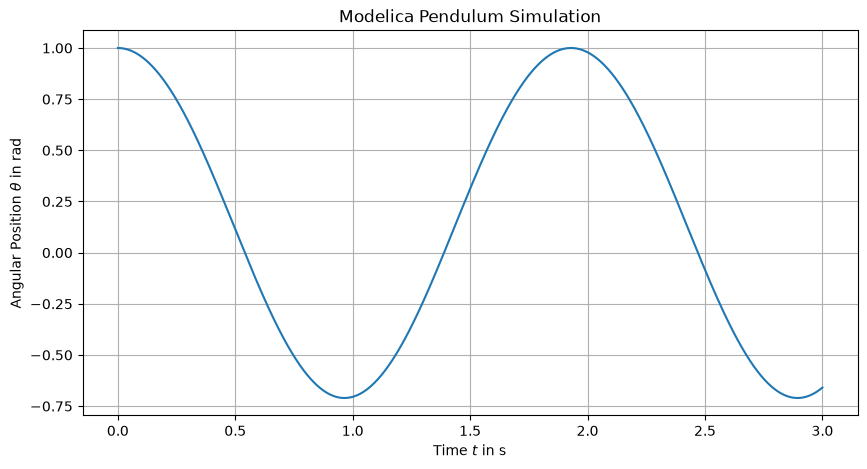

In [7]:
plt.figure(figsize=(10, 5))
plt.plot(ref_results['time'], ref_results['theta'])
plt.xlabel(r'Time $t$ in s')
plt.ylabel(r'Angular Position $\theta$ in rad')
plt.title('Modelica Pendulum Simulation')
plt.grid()
plt.show()

## Export to FMU

For this workflow we export the `ModelicaSystem` as FMI 2.0 Co-Simulation FMUs.

By default, the co-simulation FMU exported from `OMPython` uses `euler` as the solver. We also create a `cvode` FMU for comparison.

We specify the solver using the `commandLineOptions` argument of `convertMo2Fmu`:


In [8]:
modelica_cvode = ModelicaSystem(
    fileName=str(model_file),
    modelName="Pendulum",
    commandLineOptions=["--fmiFlags=s:cvode"],
)
modelica_cvode.buildModel()

modelica_euler = ModelicaSystem(
    fileName=str(model_file),
    modelName="Pendulum",
    commandLineOptions=["--fmiFlags=s:euler"],
)
modelica_euler.buildModel()

fmu_path_cvode = modelica_cvode.convertMo2Fmu(version="2.0", fmuType="cs")
fmu_path_euler = modelica_euler.convertMo2Fmu(version="2.0", fmuType="cs")


## Simulate `FMUComponents`

We run both FMUs with the same initial conditions and same constant torque input.
To show step-size effects clearly, we test two communication step sizes.


In [9]:
fmu_components = {
    "cvode": FMUComponent(name="PendulumCVODE", fmu_path=fmu_path_cvode),
    "euler": FMUComponent(name="PendulumEuler", fmu_path=fmu_path_euler),
}

dt_values = [1e-2, 1e-3, 1e-4]

fmu_results = {}

for solver_name, comp in fmu_components.items():
    fmu_results[solver_name] = {}
    for dt in dt_values:
        dt_results = {}
        comp.reset()
        comp.set_parameters(theta0=theta0, omega0=omega0)
        comp.initialize(t0=0.0)
        comp.set_inputs({'torque': torque})
        t_vals = np.arange(0.0, t_stop + dt, dt)
        for t in t_vals:
            comp.do_step(t, dt)
        history = comp.get_history()
        dt_results['theta'] = history['theta']
        fmu_results[solver_name][f"{dt}"] = dt_results

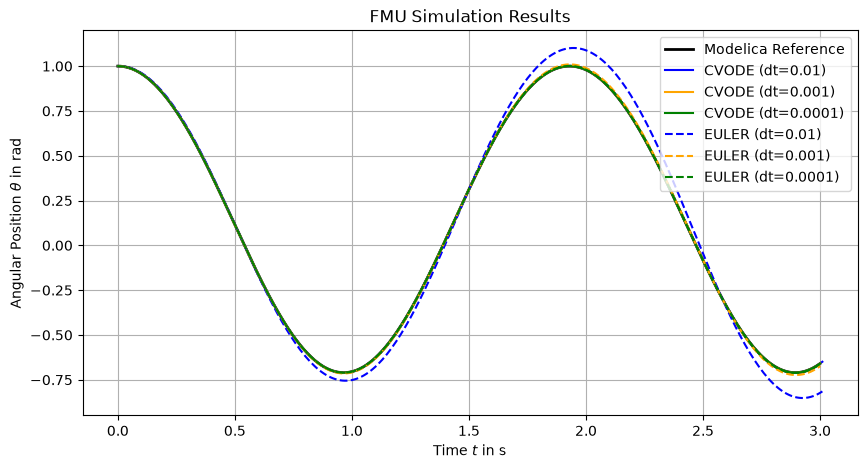

In [10]:
linestyles = {"euler": "dashed", "cvode": "solid"}
colors = {1e-2: "blue", 1e-3: "orange", 1e-4: "green"}

plt.figure(figsize=(10, 5))
plt.plot(ref_results['time'], ref_results['theta'], label='Modelica Reference', color='black', linewidth=2)

for solver_name, solver_results in fmu_results.items():
    linestyle = linestyles[solver_name]
    for dt, results in solver_results.items():
        color = colors[float(dt)]
        t_vals = results['theta']['time']
        vals = results['theta']['values']
        plt.plot(t_vals, vals, label=f'{solver_name.upper()} (dt={dt})', linestyle=linestyle, color=color)

plt.xlabel(r'Time $t$ in s')
plt.ylabel(r'Angular Position $\theta$ in rad')
plt.title('FMU Simulation Results')
plt.legend()
plt.grid()
plt.show()

We calculate the relative error compared to the Modelica reference solution for `theta`:

$$
\epsilon(t) = \frac{| \theta_{\text{FMU}}(t) - \theta_{\text{Modelica}}(t) |}{\max(|\theta_{\text{Modelica}}(t)|)}.
$$

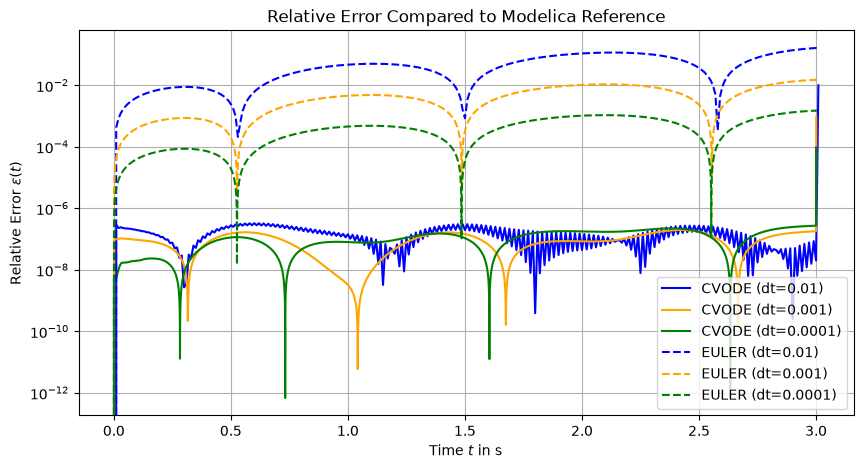

In [11]:
# claculate errors
errors = {}
for solver_name, solver_results in fmu_results.items():
    errors[solver_name] = {}
    for dt, results in solver_results.items():
        t_vals = results['theta']['time']
        vals = results['theta']['values']
        ref_interp = np.interp(t_vals, ref_results['time'], ref_results['theta'])
        error = np.abs(vals - ref_interp) / np.max(np.abs(ref_interp))
        errors[solver_name][dt] = error

plt.figure(figsize=(10, 5))
for solver_name, solver_errors in errors.items():
    linestyle = linestyles[solver_name]
    for dt, error in solver_errors.items():
        color = colors[float(dt)]
        t_vals = fmu_results[solver_name][dt]['theta']['time']
        plt.semilogy(t_vals, error, label=f'{solver_name.upper()} (dt={dt})', linestyle=linestyle, color=color)
plt.xlabel(r'Time $t$ in s')
plt.ylabel(r'Relative Error $\epsilon(t)$')
plt.title('Relative Error Compared to Modelica Reference')
plt.legend()
plt.grid()
plt.show()

## Conclusion

We have simulated the Modelica pendulum model both directly and via FMU co-simulation, comparing solver behaviors and step-size effects.

The figure above shows the relative errors in the pendulum angle `theta` for different solvers and step sizes compared to the reference solution obtained from the direct Modelica simulation using the `dassl` solver with a small tolerance.

It can be concluded that:
- The `cvode` solver performs significantly better than the `euler` solver for the same step sizes.
- Decreasing the step size improves accuracy for both solvers, but `cvode` achieves lower errors even at larger step sizes.
- The direct Modelica simulation with `dassl` provides a reliable reference solution for comparison.

We will see in the later tutorials how these solver characteristics impact hybrid simulations and rollback scenarios.

Next: {doc}`02_modelica_pendulum_contact` adds a Modelica state event before the rollback and hybrid-localization tutorials.
